In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df = pd.read_csv('train.csv')

In [11]:
corr = df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(corr)

target                 1.000000
loan_to_income         0.228331
interest_burden        0.217366
num_7                  0.204764
credit_income_ratio    0.148417
num_3                  0.126635
num_6                  0.042398
num_9                  0.031735
num_8                  0.000301
id                    -0.000262
num_4                 -0.048218
num_2                 -0.149350
num_5                 -0.150322
num_1                 -0.261188
Name: target, dtype: float64


In [4]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

# Existing Features
df['loan_to_income'] = df['num_3'] / (df['num_2'] + 1)

df['interest_burden'] = df['num_7'] * df['num_3']

df['credit_income_ratio'] = df['num_4'] / (df['num_2'] + 1)


In [5]:
TARGET = 'target'

# Drop ID
X = df.drop(columns=[TARGET, 'id'])
y = df[TARGET]

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

cat_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("\nNumerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)


Numerical Columns:
['num_1', 'num_2', 'num_3', 'num_4', 'num_5', 'num_6', 'num_7', 'num_8', 'num_9', 'loan_to_income', 'interest_burden', 'credit_income_ratio']

Categorical Columns:
['cat_1', 'cat_2', 'cat_3', 'cat_4', 'cat_5', 'cat_6', 'cat_7']


D:\Users\bsi80272\AppData\Local\Temp\ipykernel_17804\1589683289.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(


In [8]:
# Numerical
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [9]:
#tuning logreg
models = {
    'Logistic Regression': LogisticRegression(C=0.1, solver='liblinear',
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )

}

TRAINING: Logistic Regression

ROC-AUC: 0.7581

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      4600
           1       0.65      0.54      0.59      3000

    accuracy                           0.70      7600
   macro avg       0.69      0.68      0.68      7600
weighted avg       0.70      0.70      0.70      7600



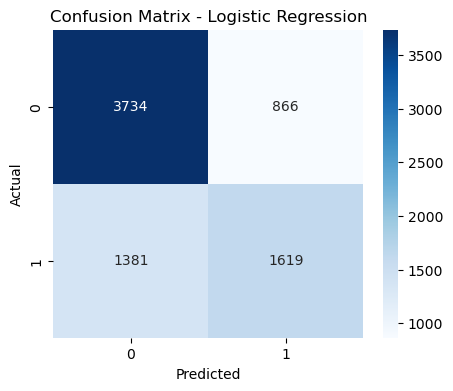

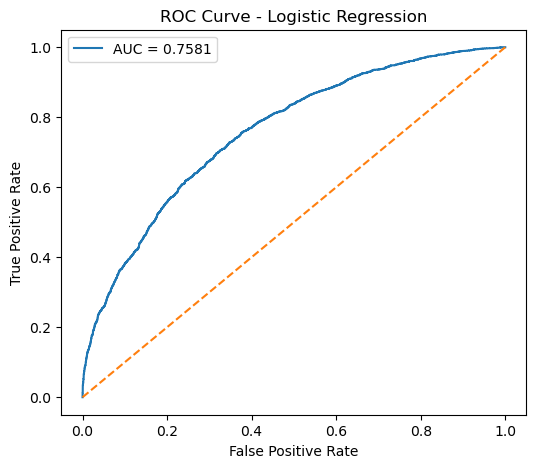

TRAINING: Random Forest

ROC-AUC: 0.7448

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.82      0.77      4600
           1       0.65      0.49      0.56      3000

    accuracy                           0.69      7600
   macro avg       0.68      0.66      0.66      7600
weighted avg       0.69      0.69      0.68      7600



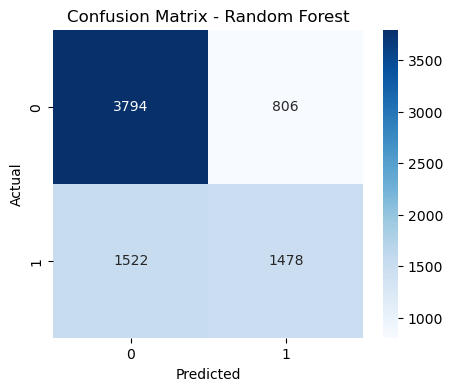

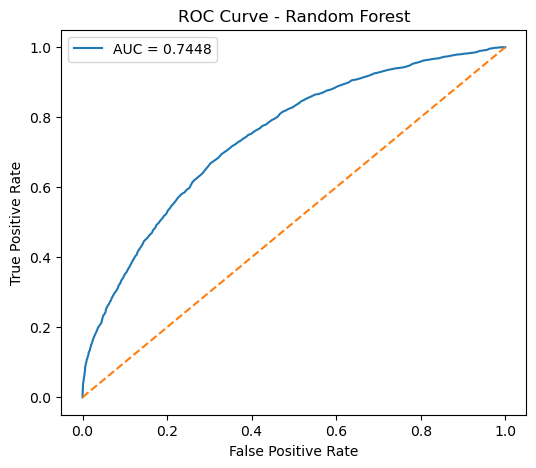

TRAINING: XGBoost

ROC-AUC: 0.7480

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.80      0.76      4600
           1       0.63      0.53      0.58      3000

    accuracy                           0.69      7600
   macro avg       0.68      0.67      0.67      7600
weighted avg       0.69      0.69      0.69      7600



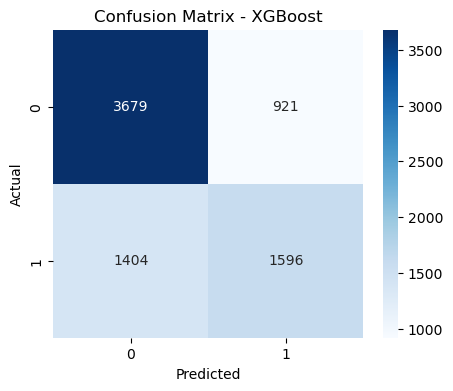

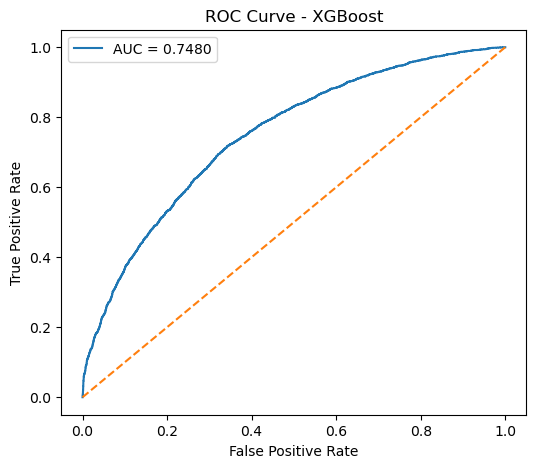

In [10]:
results = []

for model_name, model in models.items():

    print("=" * 60)
    print(f"TRAINING: {model_name}")

    # Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict Probabilities
    y_prob = pipeline.predict_proba(X_valid)[:, 1]

    # Predict Classes
    y_pred = pipeline.predict(X_valid)

    # ROC-AUC
    roc_auc = roc_auc_score(y_valid, y_prob)

    # Save Results
    results.append({
        'Model': model_name,
        'ROC-AUC': roc_auc
    })

    print(f"\nROC-AUC: {roc_auc:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_valid, y_pred))

    # -----------------------------------------------------
    # Confusion Matrix
    # -----------------------------------------------------

    cm = confusion_matrix(y_valid, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # -----------------------------------------------------
    # ROC Curve
    # -----------------------------------------------------

    fpr, tpr, thresholds = roc_curve(y_valid, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1], [0,1], linestyle='--')

    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    plt.legend()

    plt.show()